<h1>Netflix-Analysis</h1>

<h2>Importing the data and geting the data cleaned and ready to use</h2>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [32]:
df.shape

(8807, 12)

In [33]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [34]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [35]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [36]:
df = df.fillna({
    'director': 'Unknown',
    'cast': 'Unknown',
    'country': 'Unknown',
    'rating': 'Unknown'
})

In [37]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [38]:
df.dropna(inplace=True)
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

In [39]:
df.shape

(8794, 14)

<h2>Movies vs TV Shows Comaparison </h2>

In [40]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6128
TV Show    2666
Name: count, dtype: int64


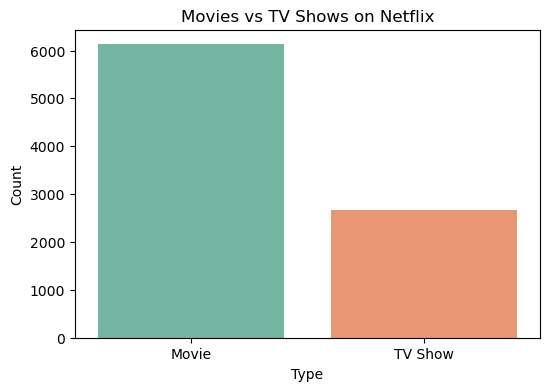

In [41]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

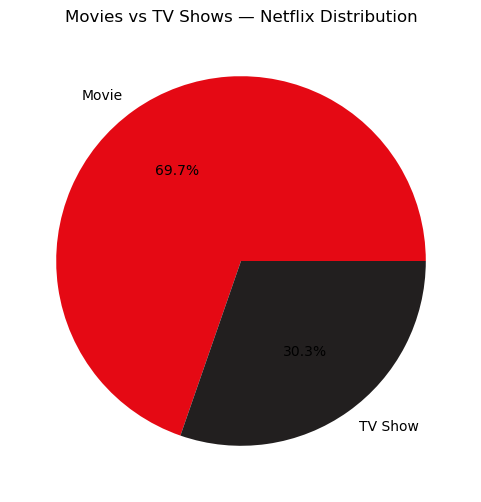

In [14]:
plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#e50914', '#221f1f'])
plt.title('Movies vs TV Shows — Netflix Distribution')
plt.show()

<h2>Observation</h2>
Netflix is heavily movie-dominated. Nearly 7 out of every 10 titles on the platform is a movie. TV Shows make up around a third of the entire catalogue. This suggests Netflix's core content strategy was built around films, not series.

<h2>Netflix's Growth Over Years </h2>

In [42]:
yearly_content = df['year_added'].value_counts().sort_index()
print(yearly_content)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     427
2017.0    1187
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


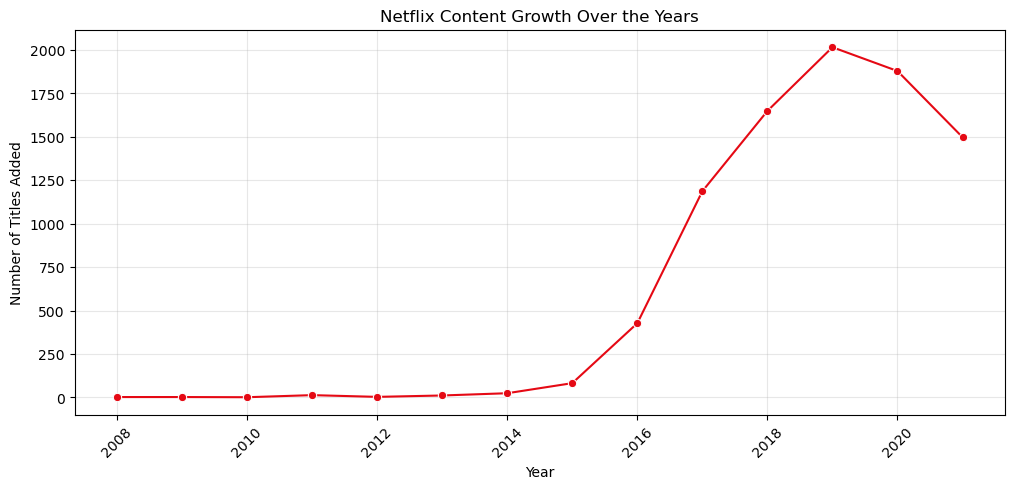

In [43]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly_content.index, y=yearly_content.values, marker='o', color='#e50914')
plt.title('Netflix Content Growth Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

Netflix was small and slow in its early streaming years, aggressively expanded from 2015-2019, hit peak in 2019, then slowed down. The slowdown after 2019 is partly because of COVID disrupting production, and partly because the dataset itself ends around 2021.

In [44]:
print("Mean titles per year:", round(yearly_content.mean(), 2))
print("Median titles per year:", round(yearly_content.median(), 2))
print("Best year:", yearly_content.idxmax())
print("Titles in best year:", yearly_content.max())

Mean titles per year: 628.14
Median titles per year: 53.0
Best year: 2019.0
Titles in best year: 2016


<h2>Observations</h2>
On 2019 being the peak:
2019 was Netflix's biggest content push ever — 2016 titles in a single year. That's roughly 5-6 new titles every single day.

Mean = 628, Median = 53. Mean is nearly 12x higher than the median. This is a massive gap and it tells you something important.
This means the distribution is heavily right-skewed. Most years Netflix added very few titles (early years like 2008-2014 had almost nothing), but the later years like 2018, 2019, 2020 had thousands. Those big years are pulling the mean up while the median stays low.
In this situation, median is the more honest number — it tells you what a "typical" year actually looked like, not the inflated average.

<h2>Netflix Content Produced By Countries Comparison</h2>

In [18]:
country_counts = df['country'].value_counts().head(10)
print(country_counts)

country
United States     2809
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


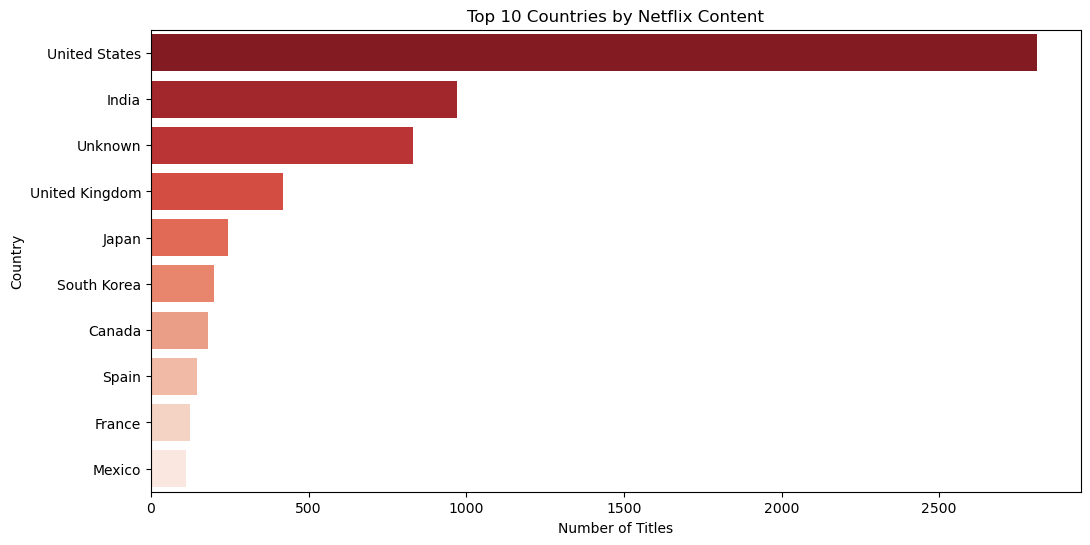

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette='Reds_r', legend=False)
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

In [20]:
total = df.shape[0]
for country, count in country_counts.items():
    print(f"{country}: {count} titles — {round((count/total)*100, 2)}%")

United States: 2809 titles — 31.94%
India: 972 titles — 11.05%
Unknown: 830 titles — 9.44%
United Kingdom: 418 titles — 4.75%
Japan: 244 titles — 2.77%
South Korea: 199 titles — 2.26%
Canada: 181 titles — 2.06%
Spain: 145 titles — 1.65%
France: 124 titles — 1.41%
Mexico: 110 titles — 1.25%


<h2>Observations</h2>
The United States dominates Netflix's content library with 2809 titles, nearly 32% of all content on the platform. India comes in at a distant second with 972 titles (11%), reflecting Netflix's aggressive Bollywood expansion around 2018-2020. The "Unknown" category at 9.44% highlights a real data quality gap in the dataset. The UK (4.75%), Japan (2.77%), and South Korea (2.26%) follow, though their numbers likely underrepresent their actual contribution given that the K-drama and anime boom largely happened after this dataset was collected. The top 10 countries combined account for roughly 68% of all Netflix content.


<h2>Top Genres Comparison</h2>

In [21]:
genres = df['listed_in'].str.split(', ').explode().value_counts().head(15)
print(genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  574
Crime TV Shows               469
Kids' TV                     449
Docuseries                   394
Name: count, dtype: int64


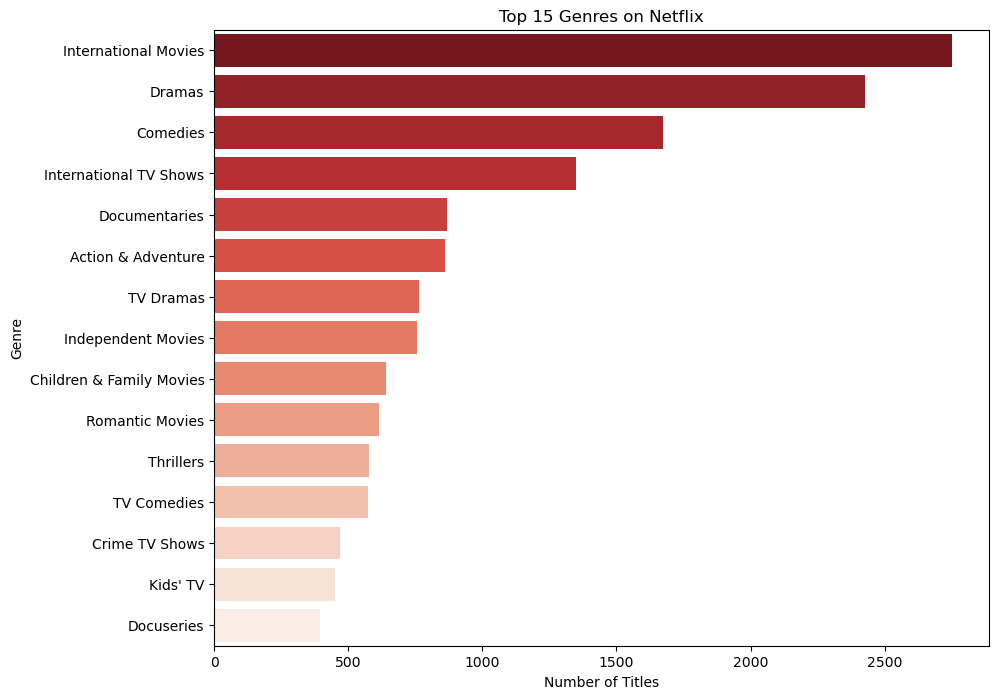

In [22]:
plt.figure(figsize=(10, 8))
sns.barplot(x=genres.values, y=genres.index, hue=genres.index, palette='Reds_r', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

In [23]:
for genre, count in genres.items():
    print(f"{genre}: {count} titles — {round((count/total)*100, 2)}%")

International Movies: 2752 titles — 31.29%
Dramas: 2427 titles — 27.6%
Comedies: 1674 titles — 19.04%
International TV Shows: 1350 titles — 15.35%
Documentaries: 869 titles — 9.88%
Action & Adventure: 859 titles — 9.77%
TV Dramas: 762 titles — 8.66%
Independent Movies: 756 titles — 8.6%
Children & Family Movies: 641 titles — 7.29%
Romantic Movies: 616 titles — 7.0%
Thrillers: 577 titles — 6.56%
TV Comedies: 574 titles — 6.53%
Crime TV Shows: 469 titles — 5.33%
Kids' TV: 449 titles — 5.11%
Docuseries: 394 titles — 4.48%


<h2>Observations</h2>
International Movies dominate the genre chart, directly mirroring the country analysis, Netflix's global expansion created a flood of non-English content. Dramas come in at a strong second place, which makes sense as dramas are the backbone of any streaming platform and the most binge-worthy genre. Comedies follow at third, driven by their universal appeal across cultures and languages. International TV Shows at fourth reflects the rise of K-dramas, anime, and Spanish thrillers like Money Heist. Documentaries round out the top 5, Netflix invested heavily in them during 2017-2020 as cheap, high-volume original content. Action & Adventure, despite being culturally prominent, just missed the top 5 — likely because the dataset predates Netflix's major push into big-budget action originals post-2021.

<h2>Netflix Movie Duration Comparison</h2>

In [24]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration'] = movies_df['duration'].str.replace(' min', '').astype(int)
print(movies_df['duration'].describe())

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64


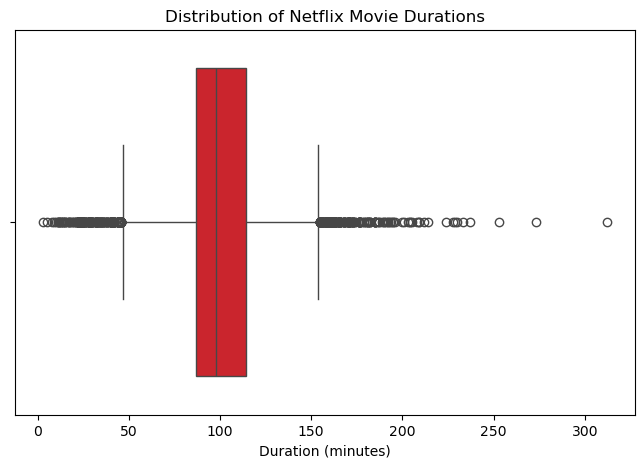

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=movies_df['duration'], color='#e50914')
plt.title('Distribution of Netflix Movie Durations')
plt.xlabel('Duration (minutes)')
plt.show()

<h2>Observations</h2>
Netflix movies have a mean duration of 99.57 minutes and a median of 98 minutes — nearly identical, which tells us the distribution is symmetric with no significant skew. The IQR is 27 minutes, meaning the middle 50% of all movies fall between 87 and 114 minutes, a tight range showing most Netflix movies cluster around the 100 minute mark. The standard deviation of 28.29 means most movies fall within 99 ± 28 minutes (roughly 71 to 128 minutes). Using the IQR method, outlier boundaries are 46.5 minutes (lower) and 154.5 minutes (upper), the minimum of 3 minutes and maximum of 312 minutes confirm outliers exist on both ends.

<h2>Netflix's India Focus</h2>

In [45]:
india_df = df[df['country'] == 'India'].copy()
print("Total Indian titles:", india_df.shape[0])
print("\nMovies vs TV Shows:")
print(india_df['type'].value_counts())

Total Indian titles: 972

Movies vs TV Shows:
type
Movie      893
TV Show     79
Name: count, dtype: int64


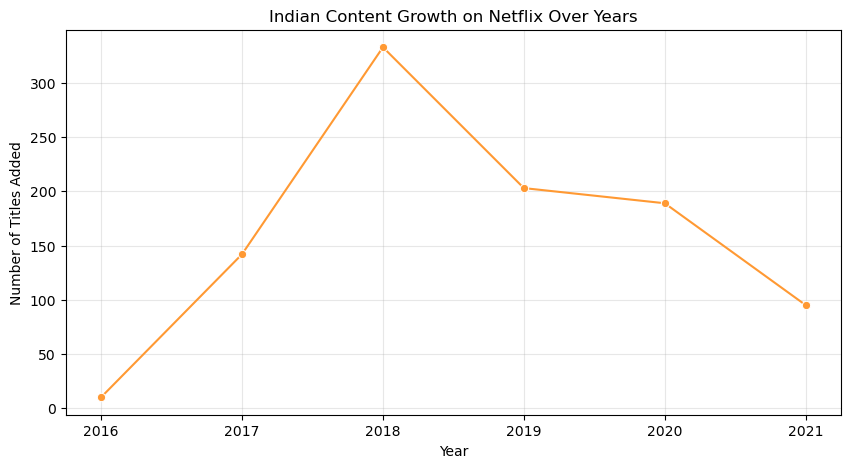

In [46]:
india_yearly = india_df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=india_yearly.index, y=india_yearly.values, marker='o', color='#ff9933')
plt.title('Indian Content Growth on Netflix Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha=0.3)
plt.show()

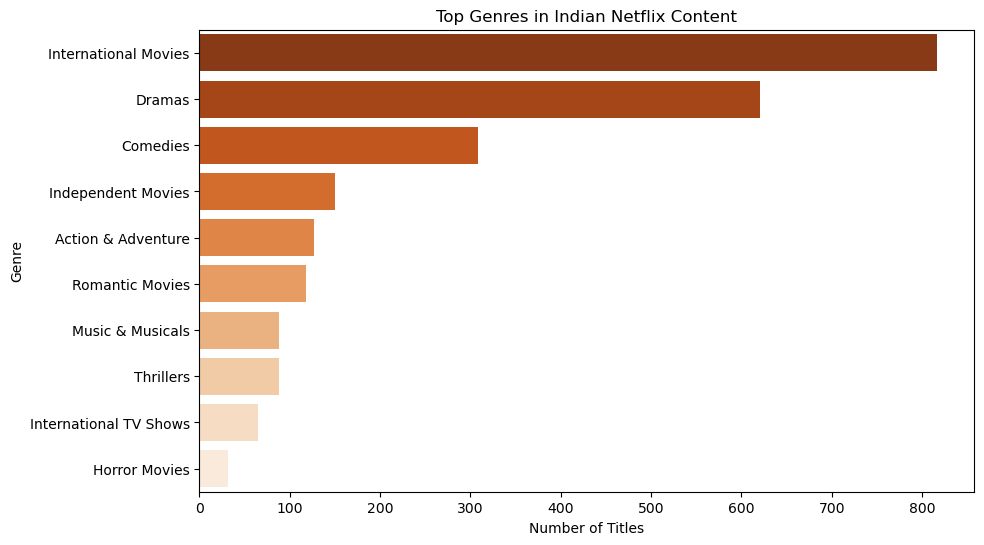

In [47]:
india_genres = india_df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=india_genres.values, y=india_genres.index, hue=india_genres.index, palette='Oranges_r', legend=False)
plt.title('Top Genres in Indian Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

In [48]:
india_ratings = india_df['rating'].value_counts()
print(india_ratings)

rating
TV-14       550
TV-MA       248
TV-PG       134
TV-Y7        14
TV-G          9
TV-Y          5
PG-13         4
NR            4
PG            2
R             1
TV-Y7-FV      1
Name: count, dtype: int64


<h2>Observations</h2>
India's 972 titles are overwhelmingly movies (893) vs TV shows (79), reflecting Bollywood's massive film output. Netflix entered India in 2016 with just 11 titles and peaked in 2018 with 330 titles added in a single year, suggesting a bulk licensing strategy early on. Top genres mirror Bollywood's DNA: International Movies, Dramas, Comedies, and uniquely, Music & Musicals, a genre that barely appears in any other country's chart. Most Indian content is rated TV-14 (550 titles), confirming that Bollywood targets mass family audiences rather than mature-only viewers.